# Computational Linear Algebra: PCA Homework

## Exercise 0.0: Initialization
Fill the missing values in this text box. **Remove the information of the second student if you are not working in a team**.

**Academic Year:** 2025/2026

### Team Members (Alphabetical Order):
1. Ozkan, Omer (360761);
2. Ulas, Zeynep Sude (364189).

Now, fill the python list below with the Student IDs of the team

In [1]:
StudentIDs = [364189,360761]  # <-------- Fill this list with Student IDs of the team

# Our student IDS

## Exercise 0.1: Starting Code-Cell 

Download the .csv files from the web page of the course (*responses_hw.csv* and *columns_hw.csv*) and past them in **the same folder of this notebook**.


Then, run the cell below, **without modifing any line of code**.

The output of this code cell is **your personal subset of the original dataset**, with 2/3 of the original features (i.e., columns) and 3/4 of the original persons (i.e., rows).

### ATTENTION: DO NOT CHANGE THE CODE INSIDE THE FOLLOWING CELL, ANY CHANGE CAN INVALIDATE THE HOMEWORK!

In [2]:
####################################################################
############## DO NOT CHANGE THE CODE IN THIS CELL #################
####################################################################

import numpy as np
import pandas as pd
from IPython.display import display

var_entertainment_feat_types = ['Interests', 'Movies', 'Music']
var_personal_feat_types = ['Finance', 'Phobias']
fixed_feat_types = ['Personality', 'Health']

label_types = ['Demographic']

variables_by_type = {
    'Demographics': ['Age', 'Height', 'Weight', 'Number of siblings', 
                     'Gender', 'Hand', 'Education', 'Only child', 'Home Town Type',
                     'Home Type'],
    'Finance': ['Finances', 'Shopping centres', 'Branded clothing', 
                'Entertainment spending', 'Spending on looks', 
                'Spending on gadgets', 'Spending on healthy eating'],
    'Health': ['Smoking', 'Alcohol', 'Healthy eating'],
    'Interests': ['History', 'Psychology', 'Politics', 'Mathematics', 
                  'Physics', 'Internet', 'PC', 'Economy Management', 
                  'Biology', 'Chemistry', 'Reading', 'Geography', 
                  'Foreign languages', 'Medicine', 'Law', 'Cars', 
                  'Art exhibitions', 'Religion', 'Countryside, outdoors', 
                  'Dancing', 'Musical instruments', 'Writing', 'Passive sport', 
                  'Active sport', 'Gardening', 'Celebrities', 'Shopping', 
                  'Science and technology', 'Theatre', 'Fun with friends', 
                  'Adrenaline sports', 'Pets'],
    'Movies': ['Movies', 'Horror', 'Thriller', 'Comedy', 'Romantic', 
               'Sci-fi', 'War', 'Fantasy/Fairy tales', 'Animated', 
               'Documentary', 'Western', 'Action'],
    'Music': ['Music', 'Slow songs or fast songs', 'Dance', 'Folk', 
              'Country', 'Classical music', 'Musical', 'Pop', 'Rock', 
              'Metal or Hardrock', 'Punk', 'Hiphop, Rap', 'Reggae, Ska', 
              'Swing, Jazz', 'Rock n roll', 'Alternative', 'Latino', 
              'Techno, Trance', 'Opera'],
    'Personality': ['Daily events', 'Prioritising workload', 
                    'Writing notes', 'Workaholism', 'Thinking ahead', 
                    'Final judgement', 'Reliability', 'Keeping promises', 
                    'Loss of interest', 'Friends versus money', 'Funniness', 
                    'Fake', 'Criminal damage', 'Decision making', 'Elections', 
                    'Self-criticism', 'Judgment calls', 'Hypochondria', 
                    'Empathy', 'Eating to survive', 'Giving', 
                    'Compassion to animals', 'Borrowed stuff', 
                    'Loneliness', 'Cheating in school', 'Health', 
                    'Changing the past', 'God', 'Dreams', 'Charity', 
                    'Number of friends', 'Punctuality', 'Lying', 'Waiting', 
                    'New environment', 'Mood swings', 'Appearence and gestures', 
                    'Socializing', 'Achievements', 'Responding to a serious letter', 
                    'Children', 'Assertiveness', 'Getting angry', 
                    'Knowing the right people', 'Public speaking', 
                    'Unpopularity', 'Life struggles', 'Happiness in life', 
                    'Energy levels', 'Small - big dogs', 'Personality', 
                    'Finding lost valuables', 'Getting up', 'Interests or hobbies', 
                    "Parents' advice", 'Questionnaires or polls', 'Internet usage'],
    'Phobias': ['Flying', 'Storm', 'Darkness', 'Heights', 'Spiders', 'Snakes', 
                'Rats', 'Ageing', 'Dangerous dogs', 'Fear of public speaking']
}

labels = variables_by_type['Demographics']
features_all = []
for tt in variables_by_type.keys():
    if tt != 'Demographics':
        features_all += variables_by_type[tt]

def which_features(*StudentIDs):
    random_seed = min(StudentIDs)
    np.random.seed(random_seed)
    features_ = np.random.choice(features_all, int((2 * len(features_all)) / 3), replace=False).tolist()
    features = []
    features_by_type = {tt: [] for tt in variables_by_type.keys() if tt != 'Demographics'}
    for tt in variables_by_type.keys():
        ft_list = variables_by_type[tt]
        for ii in range(len(ft_list)):
            if ft_list[ii] in features_:
                features.append(ft_list[ii])
                features_by_type[tt].append(ft_list[ii])

    return features, features_by_type

features, features_by_type = which_features(*StudentIDs)

print(f'*** THESE ARE THE {len(features)} SELECTED FEATURES (SEE VARIABLE features):')
for ff in features:
    print(f'{ff}')
print('*************************************')
print('')
print('*** SELECTED FEATURES BY TYPES (SEE VARIABLE features_by_type):')
for tt in features_by_type.keys():
    print(f'{tt}: {features_by_type[tt]}')
    print('')
print('*************************************')
print('')
print('*** THESE ARE THE LABELS (SEE VARIABLE labels):')
for ll in labels:
    print(f'{ll}')
print('*************************************')

def which_rows(df, frac, *StudentIDs):
    random_seed = min(StudentIDs)
    df_ = df.sample(frac=frac, random_state=random_seed)
    return df_

responses_hw = pd.read_csv('responses_hw.csv', index_col=0)
responses = which_rows(responses_hw, 0.75, *StudentIDs)
responses = responses.loc[:, features + labels]

responses_ft = responses.loc[:, features]
responses_lb = responses.loc[:, labels]

print('')
print('*** THIS IS YOUR PERSONAL DATASET (features AND labels TOGETHER, SEE VARIABLE responses)')
display(responses)
print('')
print('*** THIS IS YOUR PERSONAL DATASET (features, SEE VARIABLE responses_ft)')
display(responses_ft)
print('')
print('*** THIS IS YOUR PERSONAL DATASET (labels, SEE VARIABLE responses_lb)')
display(responses_lb)

random_seed = min(StudentIDs)
np.random.seed(random_seed)

your_scaler = np.random.choice(['StandardScaler', 'MinMaxScaler'])


*** THESE ARE THE 93 SELECTED FEATURES (SEE VARIABLE features):
Finances
Shopping centres
Branded clothing
Entertainment spending
Spending on looks
Spending on healthy eating
Smoking
Alcohol
History
Psychology
Physics
Internet
PC
Economy Management
Biology
Geography
Foreign languages
Medicine
Law
Cars
Art exhibitions
Countryside, outdoors
Writing
Passive sport
Gardening
Science and technology
Theatre
Adrenaline sports
Pets
Movies
Thriller
Romantic
Fantasy/Fairy tales
Animated
Western
Slow songs or fast songs
Dance
Folk
Country
Musical
Pop
Rock
Metal or Hardrock
Punk
Hiphop, Rap
Swing, Jazz
Latino
Techno, Trance
Opera
Prioritising workload
Writing notes
Workaholism
Thinking ahead
Final judgement
Keeping promises
Funniness
Fake
Criminal damage
Eating to survive
Giving
Compassion to animals
Borrowed stuff
Loneliness
Cheating in school
Changing the past
God
Dreams
Charity
Number of friends
Punctuality
Lying
New environment
Mood swings
Appearence and gestures
Socializing
Achievements
Respon

,Finances,Shopping centres,Branded clothing,Entertainment spending,Spending on looks,Spending on healthy eating,Smoking,Alcohol,History,Psychology,...,Age,Height,Weight,Number of siblings,Gender,Hand,Education,Only child,Home Town Type,Home Type
649,3,3,2,2,2,4,tried smoking,social drinker,3,4,...,19,178,88,0,female,right,secondary school,yes,city,block of flats
605,4,4,2,5,2,3,tried smoking,drink a lot,4,2,...,22,174,83,1,male,right,college/bachelor degree,no,village,house/bungalow
9,2,2,1,3,1,2,tried smoking,never,2,2,...,17,176,60,1,female,right,primary school,no,city,block of flats
194,4,4,4,4,4,5,never smoked,social drinker,4,1,...,24,177,80,0,male,right,secondary school,yes,village,house/bungalow
514,3,4,3,3,3,3,never smoked,social drinker,2,2,...,20,197,100,1,male,right,college/bachelor degree,no,village,house/bungalow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,2,1,4,4,5,4,current smoker,social drinker,5,5,...,20,169,64,0,female,right,college/bachelor degree,yes,city,house/bungalow
394,3,4,2,2,3,2,tried smoking,social drinker,1,1,...,23,172,64,1,female,right,college/bachelor degree,no,city,block of flats
243,2,4,4,2,2,4,tried smoking,social drinker,5,2,...,18,160,50,2,female,right,primary school,no,city,block of flats
432,4,3,4,3,3,4,tried smoking,social drinker,2,3,...,19,163,50,1,female,right,secondary school,yes,city,block of flats



*** THIS IS YOUR PERSONAL DATASET (features, SEE VARIABLE responses_ft)


,Finances,Shopping centres,Branded clothing,Entertainment spending,Spending on looks,Spending on healthy eating,Smoking,Alcohol,History,Psychology,...,Personality,Finding lost valuables,Getting up,Parents' advice,Internet usage,Storm,Heights,Snakes,Rats,Fear of public speaking
649,3,3,2,2,2,4,tried smoking,social drinker,3,4,...,3,4,3,4,less than an hour a day,4,3,5,1,3
605,4,4,2,5,2,3,tried smoking,drink a lot,4,2,...,3,3,4,3,few hours a day,2,2,5,3,2
9,2,2,1,3,1,2,tried smoking,never,2,2,...,3,3,5,4,few hours a day,1,3,5,5,5
194,4,4,4,4,4,5,never smoked,social drinker,4,1,...,4,2,4,3,less than an hour a day,3,1,4,2,4
514,3,4,3,3,3,3,never smoked,social drinker,2,2,...,4,1,2,3,few hours a day,2,2,5,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,2,1,4,4,5,4,current smoker,social drinker,5,5,...,4,4,2,3,few hours a day,4,5,5,1,3
394,3,4,2,2,3,2,tried smoking,social drinker,1,1,...,4,3,3,4,most of the day,5,3,5,4,3
243,2,4,4,2,2,4,tried smoking,social drinker,5,2,...,3,3,1,4,few hours a day,4,2,5,2,1
432,4,3,4,3,3,4,tried smoking,social drinker,2,3,...,3,3,4,3,few hours a day,3,3,5,5,1



*** THIS IS YOUR PERSONAL DATASET (labels, SEE VARIABLE responses_lb)


,Age,Height,Weight,Number of siblings,Gender,Hand,Education,Only child,Home Town Type,Home Type
649,19,178,88,0,female,right,secondary school,yes,city,block of flats
605,22,174,83,1,male,right,college/bachelor degree,no,village,house/bungalow
9,17,176,60,1,female,right,primary school,no,city,block of flats
194,24,177,80,0,male,right,secondary school,yes,village,house/bungalow
514,20,197,100,1,male,right,college/bachelor degree,no,village,house/bungalow
...,...,...,...,...,...,...,...,...,...,...
220,20,169,64,0,female,right,college/bachelor degree,yes,city,house/bungalow
394,23,172,64,1,female,right,college/bachelor degree,no,city,block of flats
243,18,160,50,2,female,right,primary school,no,city,block of flats
432,19,163,50,1,female,right,secondary school,yes,city,block of flats


## Exercise 0.2: Importing Modules

In the following cell, import all the modules you think are necessary for doing the homework, **among the ones listed and used during the laboratories of the course**.

For reproducibility, **no extra modules are allowed**.

**DO NOT IMPORT NUMPY NOR PANDAS**, they are already imported.

In [ ]:
# DO NOT IMPORT NUMPY AND PANDAS - Already imported
# import ...
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

## Exercise 1. Dataset Preprocessing

In this exercise, you have to do the following operations on the dataset of the features **responses_ft**:
1. Create a new dataframe called **responses_ft_enc** by encoding the categorical features (if they exist), motivating your choices;
1. Create a new dataframe called **responses_ft_pp** by preprocessing the data in **responses_ft_enc**, according to the scaler reported in the cell below.

In [ ]:
print(f'*** YOU HAVE TO APPLY A PREPROCESSING USING THE {your_scaler} ***')

*** YOU HAVE TO APPLY A PREPROCESSING USING THE MinMaxScaler ***


For doing this exercise, fill the cells below following the instructions you read.

#### Describe and motivate the encoding operations you will apply (max 150 words):
-   5 Features are categorical (Text), not numeric: Smoking, Alcohol, Punctuality, Lying, Internet usage
-   PCA only works with numbers, so we had to convert them first.
-   These categories have a natural order, they are not random labels. 
    -   For example: Alcohol --> "never" < "social drinker" < "drink a lot"
-   So we used **ordinal encoding** --> in ordinal encoding, each category gets a number that follows an order.
    -   For example: Alcohol --> never = 1, social drinker = 2, drink a lot = 3
-   We avoided **one-hot encoding** because it treats categories equal and unrelated. So, it would erase the order and add many extra columns
-   "Lying" was the least clear one, but we still use the same method which is go from "never" to "everytime it suits me" for consistency

#### Describe the preprocessing operation you will apply and comment the effects it may have on the data (max 150 words):
-   After encoding, our 93 features are all numeric, but their ranges differ.
    -   88 use a 1-5 scale, while the encoded categorical ones use 1-3 or 1-4.
-   PCA is based on variance, so it is sensitive to scale. A feature with a wider range can dominate the principal components, even if it is not more informative
-   Our team's assigned scaler is **MinMaxScaler** which depends on our student IDs
-   MinMaxScaler rescales each features into the 0-1 range:
    -   Formula: x' = (x - min) / (max - min)
-   **Expected effect:** every feature will be in 0-1, so no feature can dominate only because of its range
-   **Limitation:** MinMaxScaler does not force equal variance. Each feature is divided by its own range, so features with a narrow observed range are stretched more than the others
#### Write the code for performing the encoding and preprocessing operations of the exercise. Show the encoded data and the preprocessed data you obtain, plus any additional table/value that can be useful for commenting the results:

In [ ]:
# [write the code here]

"""
---- 1.ENCODING ----
"""
responses_ft_enc = responses_ft.copy() # we created the copy of the original feature dataset

# Ordinal encoding for categorical features
encoding_maps = {
    "Smoking": {"never smoked": 1, "tried smoking": 2, "former smoker": 3, "current smoker": 4},
    "Alcohol": {"never": 1, "social drinker": 2, "drink a lot": 3},
    "Punctuality": {"early": 1, "on time": 2, "late": 3},
    "Lying": {"never": 1, "only to avoid hurting someone": 2, "sometimes": 3, "everytime it suits me": 4},
    "Internet usage": {"no time at all": 1, "less than an hour a day": 2, "few hours a day": 3, "most of the day": 4}    
}

for column, mapping in encoding_maps.items():
    if column in responses_ft_enc.columns:
        responses_ft_enc[column] = responses_ft_enc[column].map(mapping)
# We encoded the our dataframe using our encoding maps

print("*** ENCODED DATASET ***")
display(responses_ft_enc)

"""
---- 2. PREPROCESSING ----
"""

scaler = StandardScaler() if your_scaler == "StandardScaler" else MinMaxScaler()
# We choice our scaler from the your_scaler variable (this variable determined according to our seed)

responses_ft_pp = pd.DataFrame(
    scaler.fit_transform(responses_ft_enc),
    columns = responses_ft_enc.columns,
    index = responses_ft_enc.index
)

print(f"*** PREPROCESSED DATASET USING {your_scaler} ***")
display(responses_ft_pp)

"""
---- 3. SUPPORTING TABLE ----
"""

comparison = pd.DataFrame({
    "min_enc": responses_ft_enc.min(),
    "max_enc": responses_ft_enc.max(),
    "variance_encoded": responses_ft_enc.var(),
    "variance_scaled": responses_ft_pp.var(),
})

print("*** VARIANCE BEFORE vs AFTER PREPROCESSING ***")
display(comparison.agg(["mean", "min", "max"]))
display(comparison.sort_values("variance_scaled", ascending=False).head(5))

*** ENCODED DATASET ***


,Finances,Shopping centres,Branded clothing,Entertainment spending,Spending on looks,Spending on healthy eating,Smoking,Alcohol,History,Psychology,...,Personality,Finding lost valuables,Getting up,Parents' advice,Internet usage,Storm,Heights,Snakes,Rats,Fear of public speaking
649,3,3,2,2,2,4,2,2,3,4,...,3,4,3,4,2,4,3,5,1,3
605,4,4,2,5,2,3,2,3,4,2,...,3,3,4,3,3,2,2,5,3,2
9,2,2,1,3,1,2,2,1,2,2,...,3,3,5,4,3,1,3,5,5,5
194,4,4,4,4,4,5,1,2,4,1,...,4,2,4,3,2,3,1,4,2,4
514,3,4,3,3,3,3,1,2,2,2,...,4,1,2,3,3,2,2,5,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,2,1,4,4,5,4,4,2,5,5,...,4,4,2,3,3,4,5,5,1,3
394,3,4,2,2,3,2,2,2,1,1,...,4,3,3,4,4,5,3,5,4,3
243,2,4,4,2,2,4,2,2,5,2,...,3,3,1,4,3,4,2,5,2,1
432,4,3,4,3,3,4,2,2,2,3,...,3,3,4,3,3,3,3,5,5,1


*** PREPROCESSED DATASET USING MinMaxScaler ***


,Finances,Shopping centres,Branded clothing,Entertainment spending,Spending on looks,Spending on healthy eating,Smoking,Alcohol,History,Psychology,...,Personality,Finding lost valuables,Getting up,Parents' advice,Internet usage,Storm,Heights,Snakes,Rats,Fear of public speaking
649,0.50,0.50,0.25,0.25,0.25,0.75,0.333333,0.5,0.50,0.75,...,0.50,0.75,0.50,0.75,0.0,0.75,0.50,1.00,0.00,0.50
605,0.75,0.75,0.25,1.00,0.25,0.50,0.333333,1.0,0.75,0.25,...,0.50,0.50,0.75,0.50,0.5,0.25,0.25,1.00,0.50,0.25
9,0.25,0.25,0.00,0.50,0.00,0.25,0.333333,0.0,0.25,0.25,...,0.50,0.50,1.00,0.75,0.5,0.00,0.50,1.00,1.00,1.00
194,0.75,0.75,0.75,0.75,0.75,1.00,0.000000,0.5,0.75,0.00,...,0.75,0.25,0.75,0.50,0.0,0.50,0.00,0.75,0.25,0.75
514,0.50,0.75,0.50,0.50,0.50,0.50,0.000000,0.5,0.25,0.25,...,0.75,0.00,0.25,0.50,0.5,0.25,0.25,1.00,0.50,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,0.25,0.00,0.75,0.75,1.00,0.75,1.000000,0.5,1.00,1.00,...,0.75,0.75,0.25,0.50,0.5,0.75,1.00,1.00,0.00,0.50
394,0.50,0.75,0.25,0.25,0.50,0.25,0.333333,0.5,0.00,0.00,...,0.75,0.50,0.50,0.75,1.0,1.00,0.50,1.00,0.75,0.50
243,0.25,0.75,0.75,0.25,0.25,0.75,0.333333,0.5,1.00,0.25,...,0.50,0.50,0.00,0.75,0.5,0.75,0.25,1.00,0.25,0.00
432,0.75,0.50,0.75,0.50,0.50,0.75,0.333333,0.5,0.25,0.50,...,0.50,0.50,0.75,0.50,0.5,0.50,0.50,1.00,1.00,0.00


*** VARIANCE BEFORE vs AFTER PREPROCESSING ***


,min_enc,max_enc,variance_encoded,variance_scaled
mean,1.010753,4.924731,1.396491,0.090485
min,1.000000,3.000000,0.252197,0.024909
max,2.000000,5.000000,2.368196,0.152895


,min_enc,max_enc,variance_encoded,variance_scaled
Punctuality,1,3,0.611580,0.152895
Pets,1,5,2.368196,0.148012
Criminal damage,1,5,2.313670,0.144604
Snakes,1,5,2.228701,0.139294
God,1,5,2.198975,0.137436


#### Comment the results obtained after the preprocessing operation (max 100 words):
-   Before scaling, the mean variance is 1.40, ranging from 0.25 to 2.37
-   After MinMaxScaler all features lie in 0-1 and the mean variance drops to 0.09, ranging from 0.025 to 0.153
-   So the differences do not disappear: the spread is still about 6 times.
-   Punctuality shows this clearly: its variance was below average before scaling (0.61 against 1.40), but it becomes the highest after scaling (0.153), because its range is only 1-3
-   MinMaxScaler equalizes the range, not the influence on PCA

## Exercise 2. Analyzing the Variance and the PCs

In this exercise, you have to do the following operations:
1. compute and visualize the variance of all the features in *responses_ft_enc* and *responses_ft_pp*;
1. compute all the $n$ Principal Components (PCs) for *responses_ft_enc* and *responses_ft_pp*, separately, and visualize the curves of the cumulative explained variances.

For doing this exercise, fill the cells below following the instructions you read.

#### Write the code for computing and visualizing the variance of the features of the two datasets:

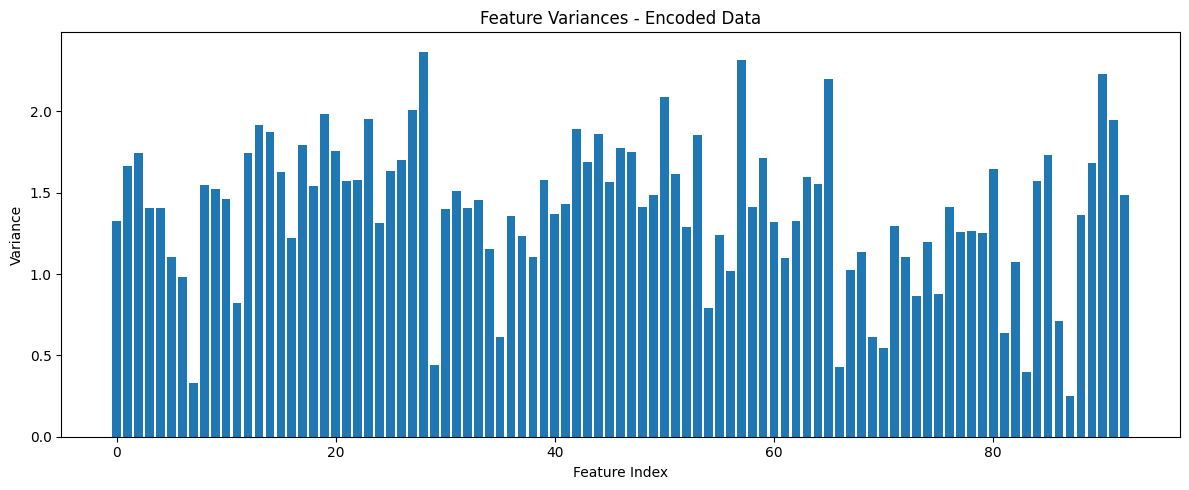

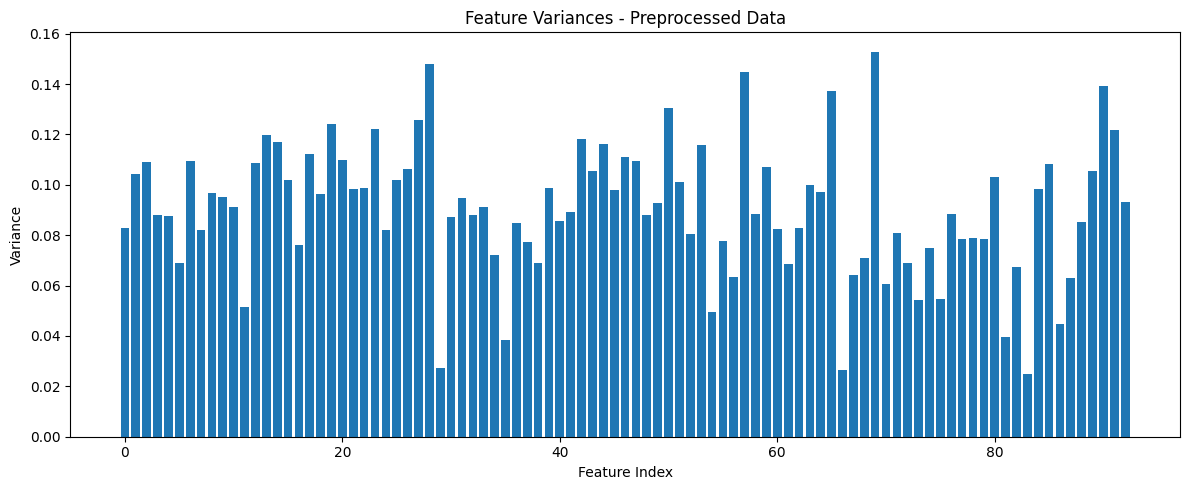

Encoded      --> mean: 1.3965  min: 0.2522  max: 2.3682
Preprocessed --> mean: 0.0905  min: 0.0249  max: 0.1529


In [ ]:
var_enc = responses_ft_enc.var()
var_pp = responses_ft_pp.var()

# Encoded Data

plt.figure(figsize=(12, 5))
plt.bar(range(len(var_enc)), var_enc)

plt.title("Feature Variances - Encoded Data")
plt.xlabel("Feature Index")
plt.ylabel("Variance")

plt.tight_layout()
plt.show()

# Preprocessed Data

plt.figure(figsize=(12, 5))
plt.bar(range(len(var_pp)), var_pp)

plt.title("Feature Variances - Preprocessed Data")
plt.xlabel("Feature Index")
plt.ylabel("Variance")

plt.tight_layout()
plt.show()

print(f"Encoded      --> mean: {var_enc.mean():.4f}  min: {var_enc.min():.4f}  max: {var_enc.max():.4f}")
print(f"Preprocessed --> mean: {var_pp.mean():.4f}  min: {var_pp.min():.4f}  max: {var_pp.max():.4f}")

#### Comment the results obtained for the variances (max 150 words):

-   In the encoded data the variances are very uneven with a mean 1.40
-   After MinMaxScaler all values are much smaller because every feature is now between 0-1
-   However, the bar plot keeps a similar uneven shape: the spread is still about 6 times. MinMaxScaler does not equalize the variance
-   The most visible change concerns the encoded categorical features (range 1-3 or 1-4): They are divided by a smaller number than the 1-5 features, so their variance grows relative to the others (Punctuality becomes the largest)
-   Consequence for PCA: the features still have different weights, so the PCs will be driven more by the high-variance features

#### Write the code for computing all the $n$ PCs of the two datasets, separately, and for visualizing the curves of cumulative explained variances:

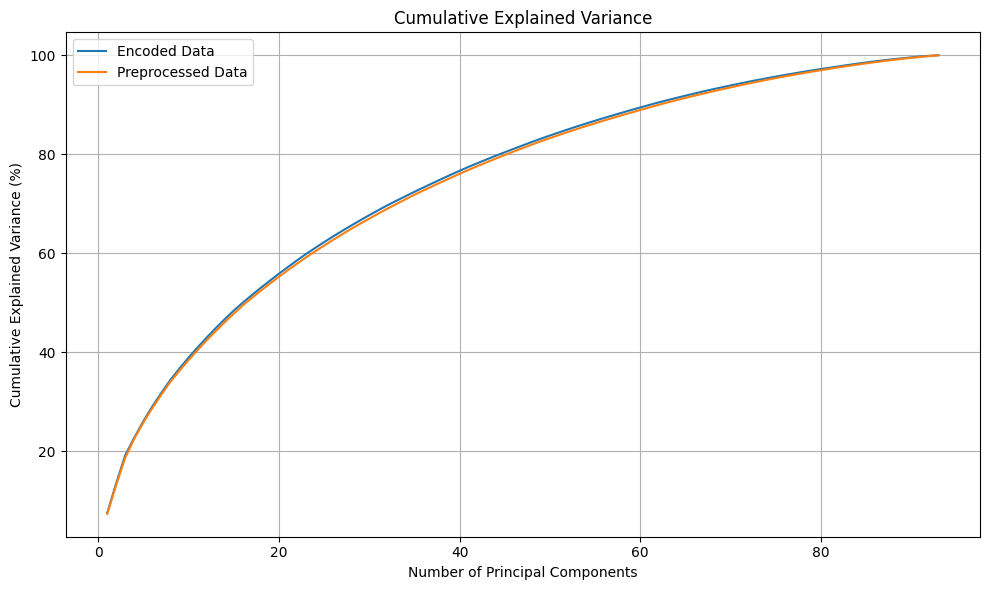

In [ ]:

# PCA for encoded data
pca_enc = PCA()
pca_enc.fit(responses_ft_enc)
# learns pc directions, variances for components, eigenvalues, eigenvectors

# PCA for preprocessed data
pca_pp = PCA()
pca_pp.fit(responses_ft_pp)

# Cumulative sum of each pca component (%)
cum_var_enc = np.cumsum(pca_enc.explained_variance_ratio_) * 100
cum_var_pp = np.cumsum(pca_pp.explained_variance_ratio_) * 100

# Plot
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cum_var_enc) + 1),
    cum_var_enc,
    label="Encoded Data"
)

plt.plot(
    range(1, len(cum_var_pp) + 1),
    cum_var_pp,
    label='Preprocessed Data'
)

plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('Cumulative Explained Variance')

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#### Comment the results obtained for the cumulative explained variances, knowing the vaues in the datasets and the fetures' variances (max 150 words):

-   The cumulative explained variance of a PCA always reaches exactly 100% with all n principal components, because it represents the total variance of the original dataset.
-   PCA is only a rotation of the data space: when all n components are kept, the data is re-described in a new basis without discarding any information, so the total variance is preserved


## Exercise 3. Dimensionality Reduction and PC Interpretation

In this exercise, you have to do the following operations:
1. For the dataset *responses_ft_pp*, compute a new PCA for performing a dimensionality reduction with respect to $m$ dimensions. The value of $m$ must be $$m = \min\{m', 5\}\,,$$ where $m'$ is the value required for obtaining $33\%$ of the total variance.
1. Visualize as a barplot the explained variance (as percentage) for each PC, and report the preserved explained variance (as percentage) by the $m$ PCs.
1. Visualize all the PCs as barplots and give an interpretation and a name to them, **motivating your choices**.
1. Transform the *responses_ft_pp* data into their $m$-dimensional representation via PCA. Store the transformed data in the variable *responses_ft_pca*;
1. Visualize the the score graph. If $m>3$, plot the score graph with respect to the first 3 PCs. All the **plots must show the names of the PCs (given at the previous step) on the axes** for better understanding the results.

#### Write the code for computing the new PCA, for visualizing the $m$ PCs as barplots:

Components needed for 33% variance (m'): 8
Components selected (m): 5


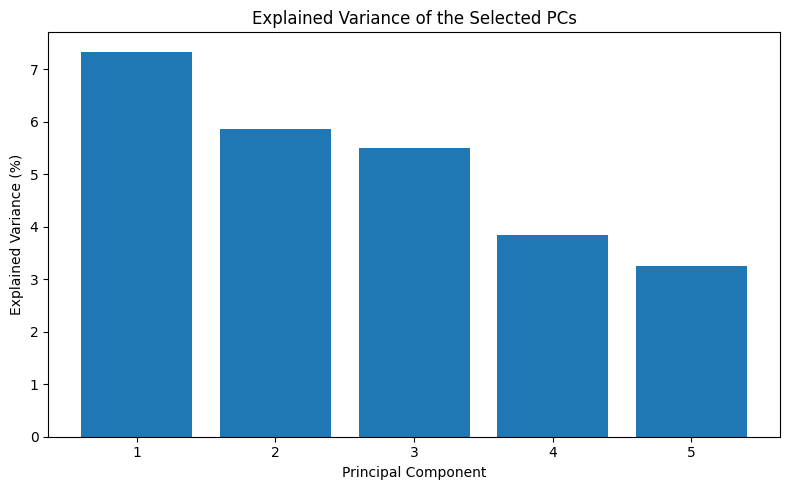

Preserved explained variance: 25.80%


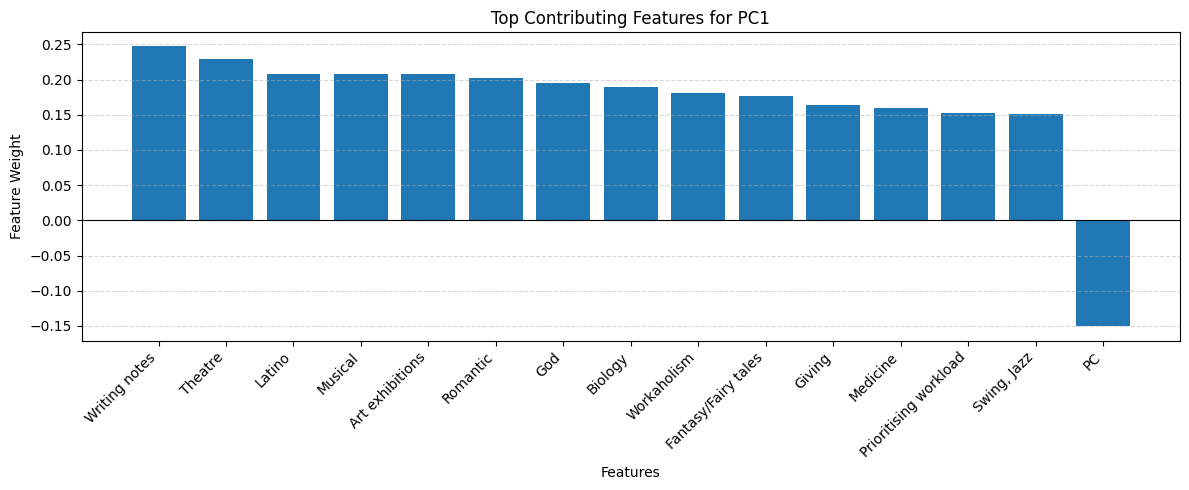

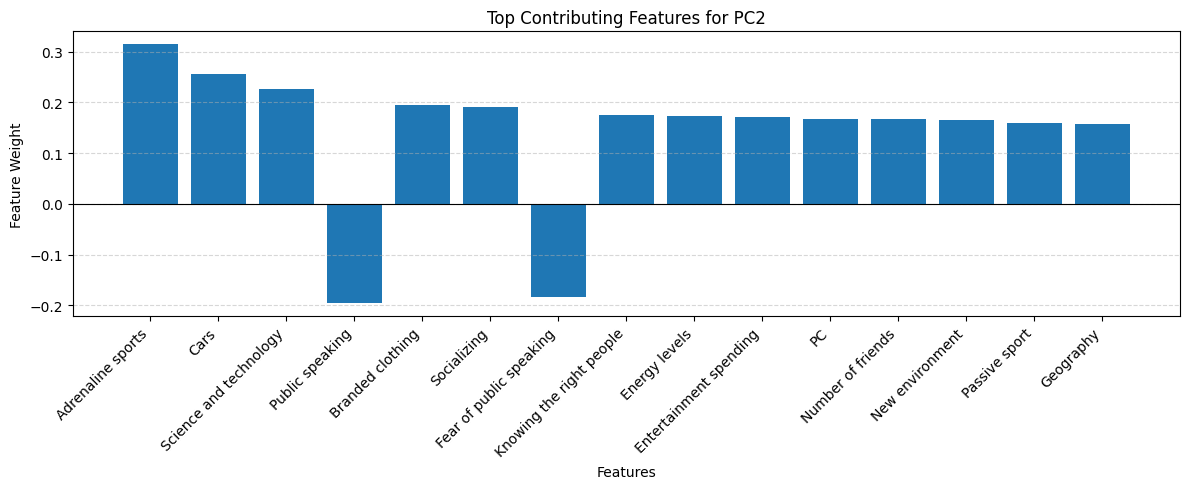

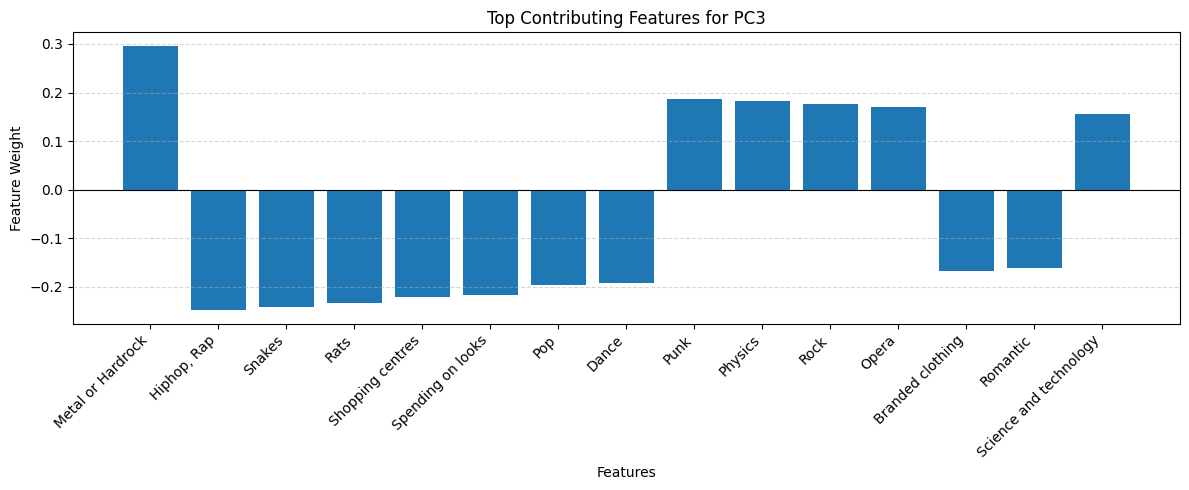

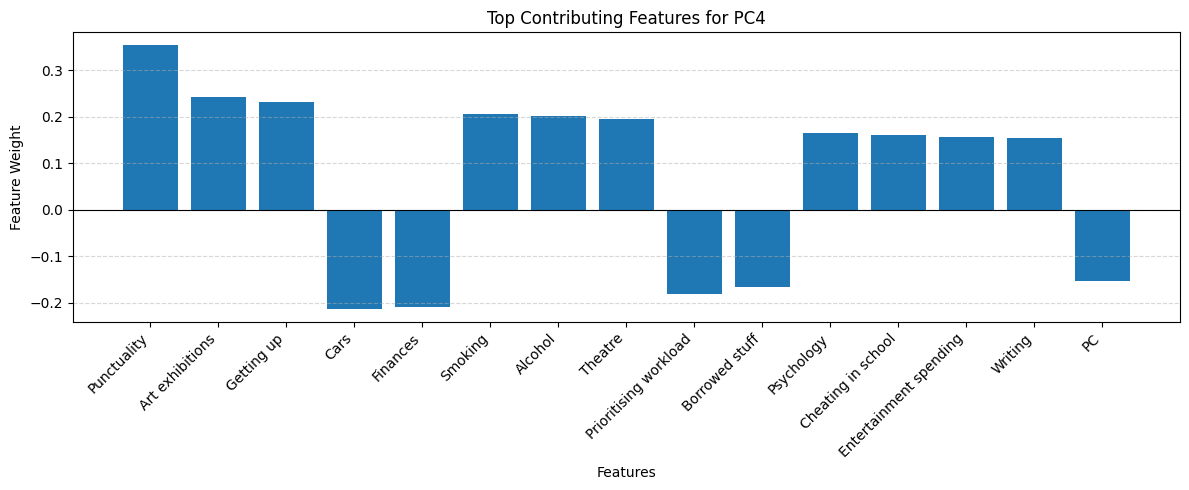

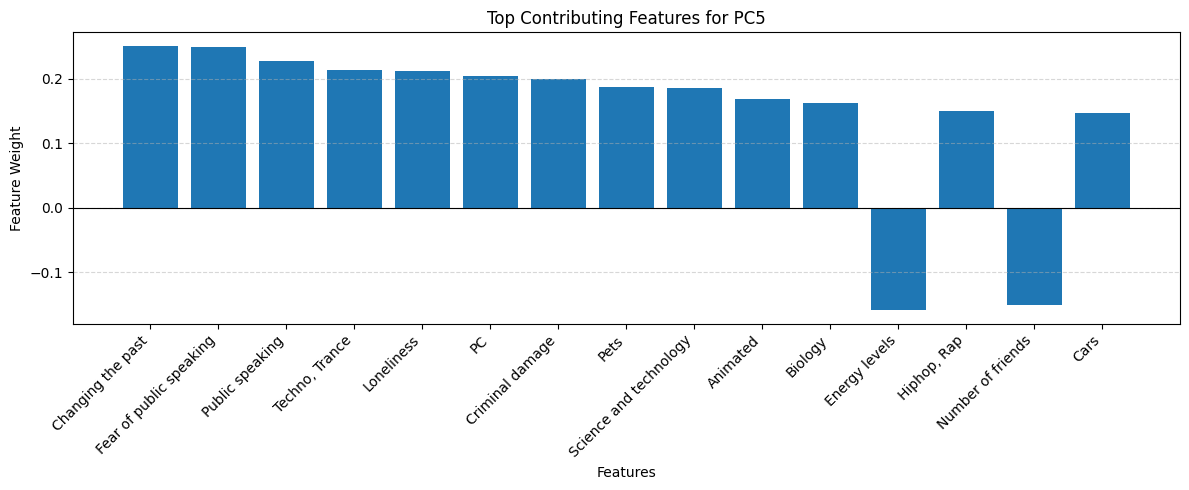


PC1
Writing notes          0.247205
Theatre                0.229876
Latino                 0.208618
Musical                0.208532
Art exhibitions        0.208426
Romantic               0.202351
God                    0.195616
Biology                0.189480
Workaholism            0.181073
Fantasy/Fairy tales    0.176075
Name: PC1, dtype: float64

PC2
Adrenaline sports           0.314787
Cars                        0.256240
Science and technology      0.226543
Public speaking            -0.195942
Branded clothing            0.195385
Socializing                 0.191615
Fear of public speaking    -0.183839
Knowing the right people    0.175311
Energy levels               0.172410
Entertainment spending      0.171060
Name: PC2, dtype: float64

PC3
Metal or Hardrock    0.296719
Hiphop, Rap         -0.248174
Snakes              -0.241493
Rats                -0.233467
Shopping centres    -0.220977
Spending on looks   -0.216883
Pop                 -0.195746
Dance               -0.192142
Pun

,PC1,PC2,PC3,PC4,PC5
649,0.906756,-0.025817,0.753879,0.322132,0.183507
605,-0.348768,0.369578,0.501981,0.549211,-0.623893
9,-0.743691,-0.867389,-0.076267,0.900243,-0.026936
194,-0.493086,0.650687,-0.199806,-0.458844,0.381445
514,-0.583987,0.115904,-0.580428,-1.253526,0.844413


In [ ]:
# *********** 1 Calculate m (Number of Components) ***********

# Cumulative explained variance from the previous PCA
cumulative_variance_ratio = np.cumsum(pca_pp.explained_variance_ratio_)

# Find the number of components needed to explain at least 33% of variance
m_prime = np.argmax(cumulative_variance_ratio >= 0.33) + 1 # we did +1 because arrays start from 0

# use max 5 comp if m_prime is bigger than 5
m = min(m_prime, 5)

print(f"Components needed for 33% variance (m'): {m_prime}")
print(f"Components selected (m): {m}")

# *********** 2 Explained variance of the selected PCs ***********

pca_m = PCA(n_components = m) 
pca_m.fit(responses_ft_pp)

# Explained variance percentage for each PC
explained_variance = pca_m.explained_variance_ratio_ * 100

# Total preserved variance
preserved_variance = np.sum(explained_variance)

# Barplot
plt.figure(figsize=(8,5))

plt.bar(
    range(1, m+1),
    explained_variance
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("Explained Variance of the Selected PCs")

plt.xticks(range(1, m + 1))

plt.tight_layout()
plt.show()

print(f"Preserved explained variance: {preserved_variance:.2f}%")


# *********** 3 Visualize the top 15 constributing features for each PC ***********

pc_names = [f"PC{i+1}" for i in range(m)]

components_df = pd.DataFrame(
    pca_m.components_,
    columns=responses_ft_pp.columns,
    index=pc_names
)

for pc in pc_names:
    # Select the 15 features with the largest absolute weights
    
    top_features = (
        components_df.loc[pc].abs().sort_values(ascending=False).head(15).index
    )
    
    # Preserve the original signs of the weights
    pc_weights = components_df.loc[pc, top_features]

    plt.figure(figsize=(12, 5))

    plt.bar(
        pc_weights.index,
        pc_weights.values
    )
    
    plt.title(f'Top Contributing Features for {pc}')
    plt.xlabel('Features')
    plt.ylabel('Feature Weight')
    plt.xticks(rotation=45, ha='right')
    plt.axhline(0, color='black', linewidth=0.8)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()
    
    loadings = pd.DataFrame(
        pca_m. components_.T,
        index = responses_ft_pp.columns,
        columns = pc_names
    )

for pc in pc_names:
    print(f"\n{pc}")
    print(loadings[pc].sort_values(key = abs, ascending=False).head(10))
    

# *********** 4 Transform the data into the m-dimensional PCA representation ***********

responses_ft_pca_array = pca_m.transform(responses_ft_pp)

responses_ft_pca = pd.DataFrame(
    responses_ft_pca_array,
    index = responses_ft_pp.index,
    columns = pc_names
)

responses_ft_pca.head().style.set_caption("PCA Representation of the Preprocessed Data")



#### For each PC, write the name you assigned to it and a brief interpretation that motivate the choice (max 100 words per PC):

-   **PC1 - Cultural Engagement**
    -   High positive loadings for Writing notes, Theatre, Latino, Musical, Art exhibitions, Romantic movies, God, Biology and Workaholism
    -   The only negative one is PC (computers)
    -   A high score describes a person with cultural and artistic interests, who is also organised and hard-working

-   **PC2 - Active Sociability**
    -   Positive loadings for Adrenaline sports, Cars, Science and technology, Branded clothing, Socializing, Knowing the right people, Energy levels and Number of friends, opposed to Public speaking and Fear of public speaking.
    -   A high score describes an energetic, adventurous and socially confident person.

-   **PC3 - Alternative and Scientific Interests**
    -   Metal, Punk, Rock, Opera, Physics and Science and technology have positive loadings, while Hip-hop, Pop, Dance, Shopping centers, Spending on looks, Branded clothing and the fears of Snakes and Rats are negative.
    -   It contrasts alternative music and scientific interests with mainstream entertainment and apperance

-   **PC4 - Undisciplined Lifestyle**
    -   The largest loading is Punctuality (high = late), followed by Getting up (difficult), Smoking, Alcohol, Cheating in school and Entertainment spending.
    -   Negative loadings: Finances (saving), Prioritising workload and Borrowed stuff (careful with borrowed things).
    -   A high score means a less disciplined lifestyle; a low score a careful and organised one. Punctuality dominates because MinMaxScaler gave it the largest variance (Exercise 1).

-   **PC5 - Social Insecurity**
    -   Positive loadings for Changing the past (regret), Fear of public speaking, Public speaking (needs preparation), Loneliness and Criminal damage (anger), with negative loadings for Energy levels and Number of friends. 
    -   A high score describes a person who feels lonely, insecure and regretful; a low score an energetic person with many friends.

#### Write the code for visualizing the score graph (with PC names on the axis):

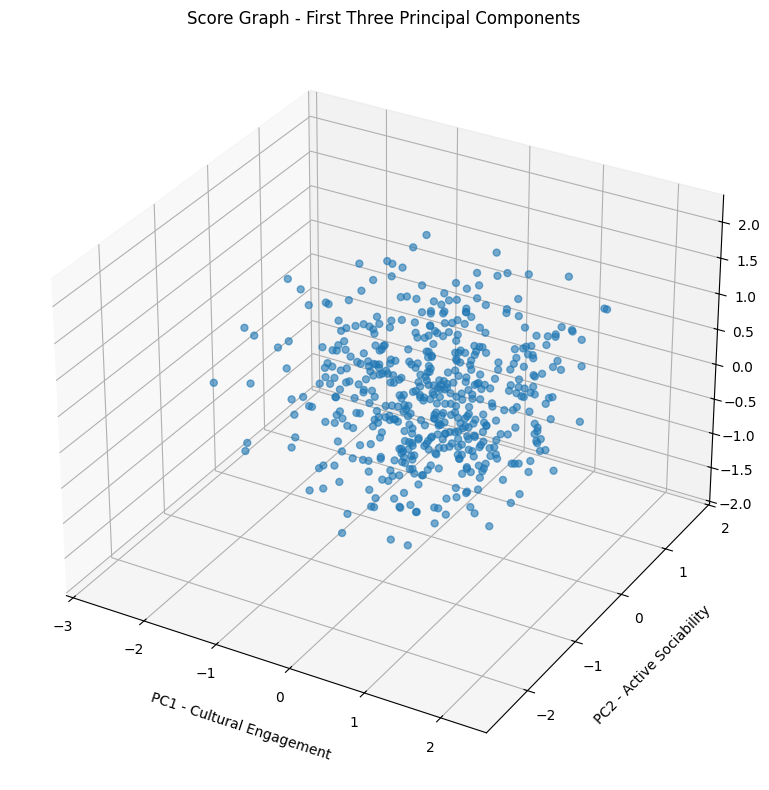

In [ ]:
# Score graph with respect to the first 3 PCs (m > 3)
# using the names assigned above

pc_labels = [
    "PC1 - Cultural Engagement",
    "PC2 - Active Sociability",
    "PC3 - Alternative and Scientific Interests",
    "PC4 - Undisciplined Lifestyle",
    "PC5 - Social Insecurity"
]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    responses_ft_pca.iloc[: , 0],
    responses_ft_pca.iloc[: , 1],
    responses_ft_pca.iloc[: , 2],
    s = 25,
    alpha = 0.6
)

ax.set_xlabel(pc_labels[0], labelpad=12)
ax.set_ylabel(pc_labels[1], labelpad=12)
ax.set_zlabel(pc_labels[2], labelpad=12)
ax.set_title("Score Graph - First Three Principal Components")

plt.tight_layout()
plt.show()

## Exercise 4. $k$-Means

In this exercise, you have to do the following operations:
1. Run the $k$-Means for clustering the data of *responses_ft_pca*, **setting the input argument *random_state* equal to the variable *random_seed*** (i.e., the minimum of the Student IDs).

   In particular, **use the silohuette score for identifying the best value for $k\in\{3, \ldots, 10\}$** and show it by plotting how the score changes w.r.t. $k$.
1. Plot the score graph again, but add the centroids of the cluster and color the points according to their cluster.
1. Visualize the centroids coordinates as barplots and **give a name and an interpretation to them by exploiting the PC names**.


#### Write the code for performing the items of the list above:

Best k: 3
Best silhouette score: 0.1656


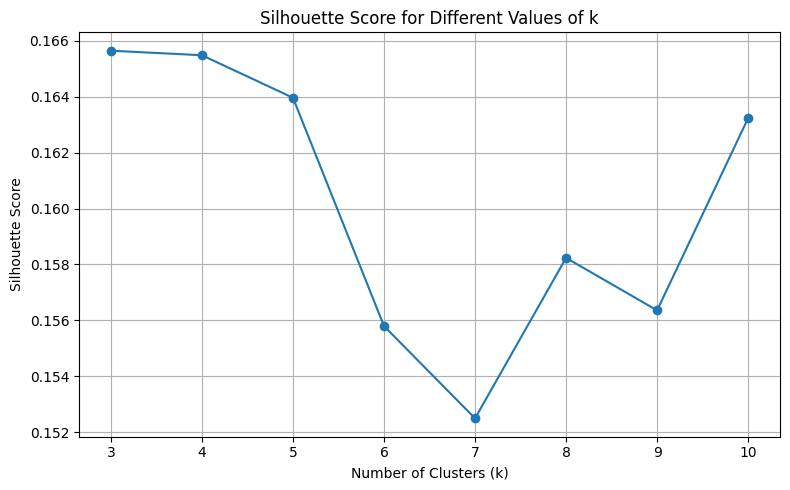

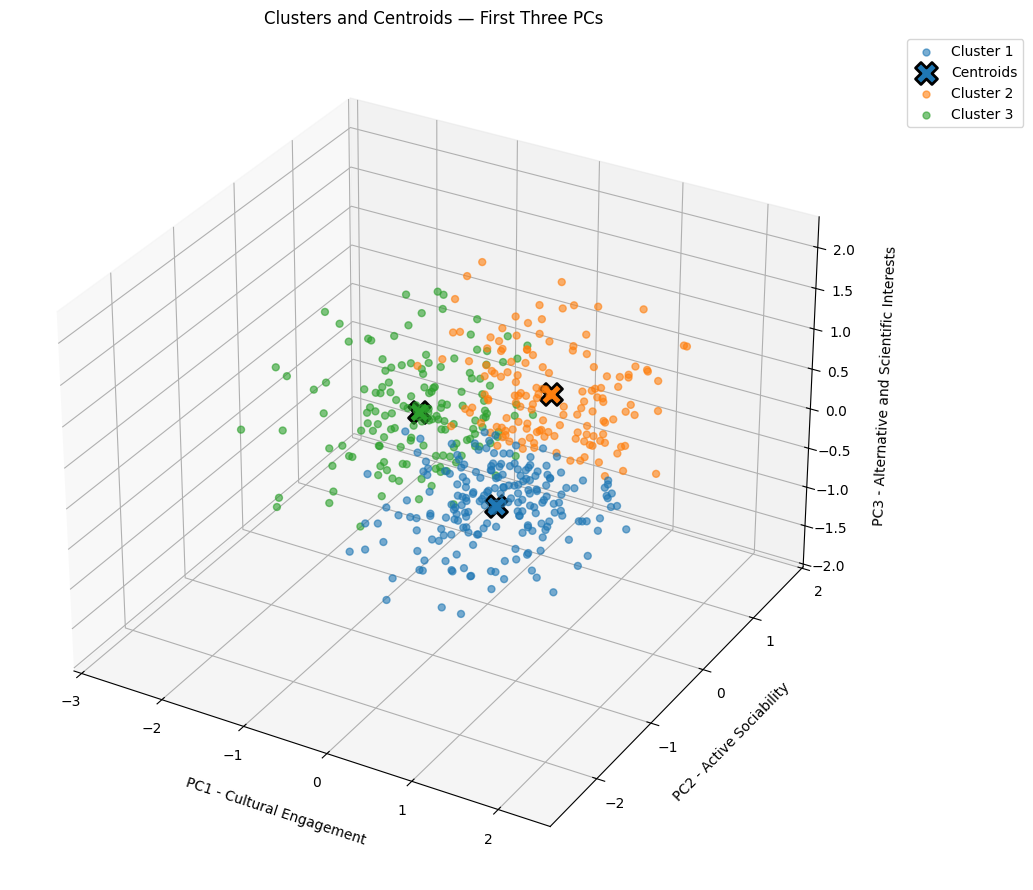

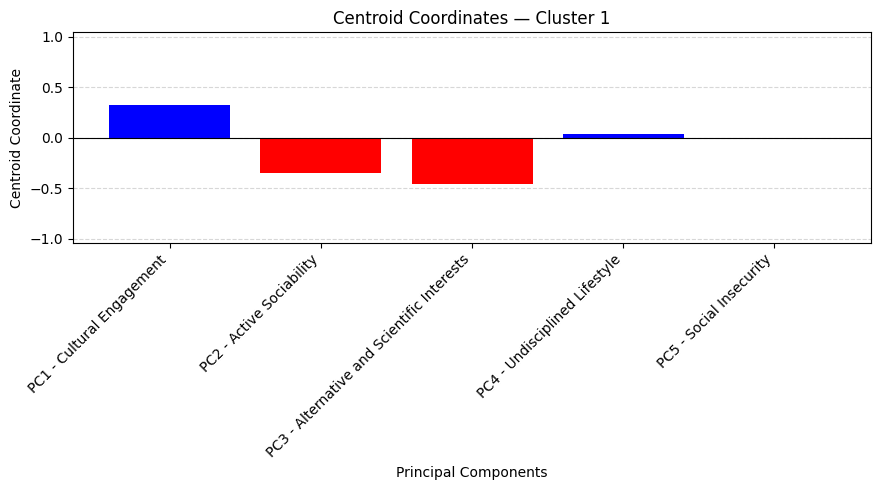

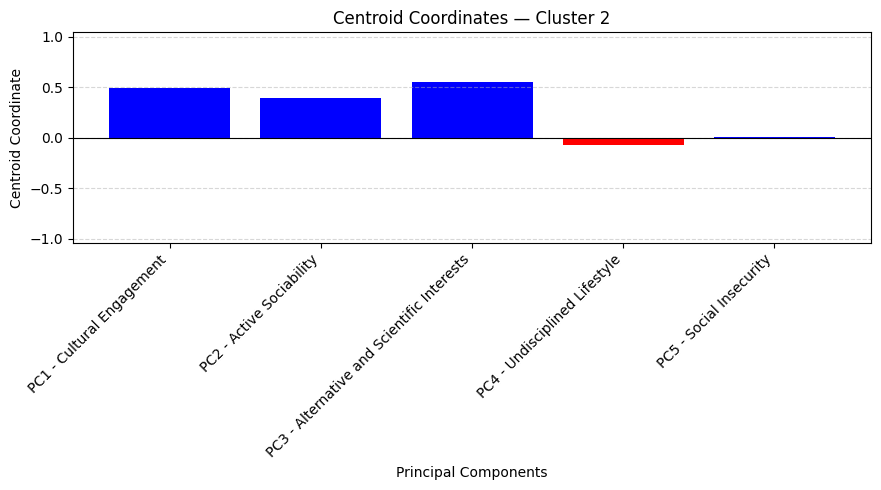

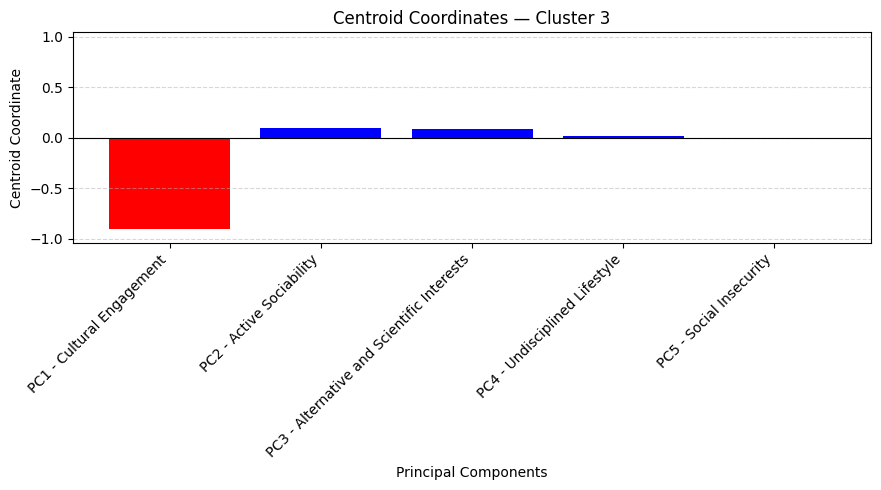

,PC1 - Cultural Engagement,PC2 - Active Sociability,PC3 - Alternative and Scientific Interests,PC4 - Undisciplined Lifestyle,PC5 - Social Insecurity
Cluster 1,0.326838,-0.346216,-0.457755,0.039024,-0.000810
Cluster 2,0.493060,0.388977,0.549718,-0.073102,0.008364
Cluster 3,-0.905726,0.089576,0.084618,0.017832,-0.006905


In [ ]:
# 4.1 Find the best k using the silhouette score

k_values = range(3, 11)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=random_seed,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(responses_ft_pca)

    score = silhouette_score(
        responses_ft_pca,
        cluster_labels
    )

    silhouette_scores.append(score)


# Best value of k
best_k = list(k_values)[np.argmax(silhouette_scores)]

print(f"Best k: {best_k}")
print(f"Best silhouette score: {max(silhouette_scores):.4f}")


# Plot silhouette score for each k
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    silhouette_scores,
    marker='o'
)

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different Values of k')

plt.xticks(k_values)
plt.grid(True)

plt.tight_layout()
plt.show()

#********************************************************************************************************
# 4.2. Plot the clusters and their centroids

# Fit K-Means using all selected PCs
final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=random_seed,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(responses_ft_pca)
centroids = final_kmeans.cluster_centers_

# Visualize the first three PCs
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

colors = plt.get_cmap('tab10')

for cluster in range(best_k):
    mask = cluster_labels == cluster

    ax.scatter(
        responses_ft_pca.iloc[mask, 0],
        responses_ft_pca.iloc[mask, 1],
        responses_ft_pca.iloc[mask, 2],
        color=colors(cluster),
        s=25,
        alpha=0.6,
        label=f'Cluster {cluster + 1}'
    )

    ax.scatter(
        centroids[cluster, 0],
        centroids[cluster, 1],
        centroids[cluster, 2],
        color=colors(cluster),
        marker='X',
        s=250,
        edgecolors='black',
        linewidths=2,
        label='Centroids' if cluster == 0 else None
    )

# Use the PC interpretation names defined in Exercise 3.5
ax.set_xlabel(pc_labels[0], labelpad=12)
ax.set_ylabel(pc_labels[1], labelpad=12)
ax.set_zlabel(pc_labels[2], labelpad=12)

ax.set_title('Clusters and Centroids — First Three PCs')
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

#********************************************************************************************************

# 4.3. Visualize centroid coordinates as barplots
pc_interpretation_names = [
    'PC1',
    'PC2',
    'PC3',
    'PC4',
    'PC5'
][:responses_ft_pca.shape[1]]

centroids_df = pd.DataFrame(
    centroids,
    columns=pc_labels,
    index=[f'Cluster {i + 1}' for i in range(len(centroids))]
)

for cluster_name, coordinates in centroids_df.iterrows():
    plt.figure(figsize=(9, 5))

    plt.bar(
        coordinates.index,
        coordinates.values,
        color=np.where(coordinates >= 0, 'blue', 'red')
    )

    plt.axhline(0, color='black', linewidth=0.8)
    plt.title(f'Centroid Coordinates — {cluster_name}')
    plt.xlabel('Principal Components')
    plt.ylabel('Centroid Coordinate')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    # Use the same scale to compare clusters
    limit = np.abs(centroids).max()
    plt.ylim(-1.15 * limit, 1.15 * limit) if limit > 0 else None

    plt.tight_layout()
    plt.show()

display(centroids_df)



#### For each Centroid, write the name you assigned to it and a brief interpretation that motivate the choice by exploiting the PC names(max 100 words per centroid):

-   **Cluster 1 - Reserved Mainstream Group**
    -   The two negative coordinates define this group: PC3 (Alternative and Scientific Interests) is clearly negative, so its members prefer mainstream music, shopping and appearance, and PC2 (Active Sociability) is negative, so they are less social and less adventurous. A moderately positive PC1 (Cultural Engagement) shows some interest in culture and organisation.

-   **Cluster 2 - Active and Curious Group**
    -   All three main coordinates are positive: PC1 (Cultural Engagement), PC2 (Active Sociability) and PC3 (Alternative and Scientific Interests), the last one being the largest. 
    -   These are sociable and energetic people, interested in culture, science and alternative music. It is the most "engaged" profile of the three.

-   **Cluster 3 - Low Cultural Engagement Group**
    -   This centroid is defined by one coordinate only: a strongly negative PC1 (Cultural Engagement), the largest absolute value in the table. 
    -   Its members show little interest in theatre, art, reading or religion and lower diligence. PC2 and PC3 are close to zero, so on sociability and music taste they are average.

## Exercise 5. Cluster External Evaluations

In this exercise, you have to do the following operations:
1. Select a subset meaningful labels for performing an external evaluation of the clustering results.
1. For each selected label, visualize the distribution of the label in each cluster and in the whole dataset.
1. Visualize the score graph with dots colored with respect to the label value; then, visualize the clusters in separated score-graphs, coloring the points according to the label values.


#### List the Labels you consider meaningful for an external cluster evaluation and motivate your choice (max 50 words per label):

-   **Gender:**
    -   Gender is selected to check whether males and females are distributed differently across the clusters. It can show whether the interests and behaviours represented by the clusters are related to gender.

-   **Home Town Type:**
    -   Home Town Type is selected to compare people from cities and villages. It can show whether the place where people live is related to their interests, social life and use of technology.

#### Write the code for the visualizations cited in item 2 above:

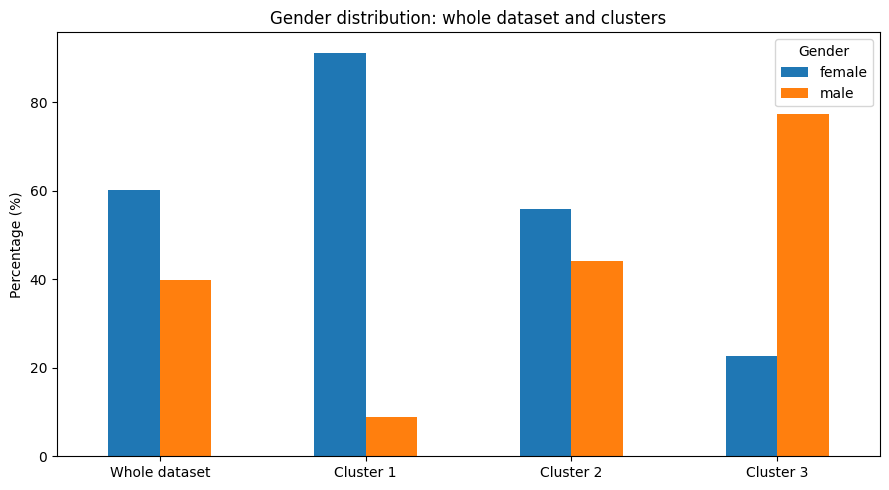

Gender,female,male
Whole dataset,60.1,39.9
Cluster 1,91.2,8.8
Cluster 2,55.8,44.2
Cluster 3,22.7,77.3


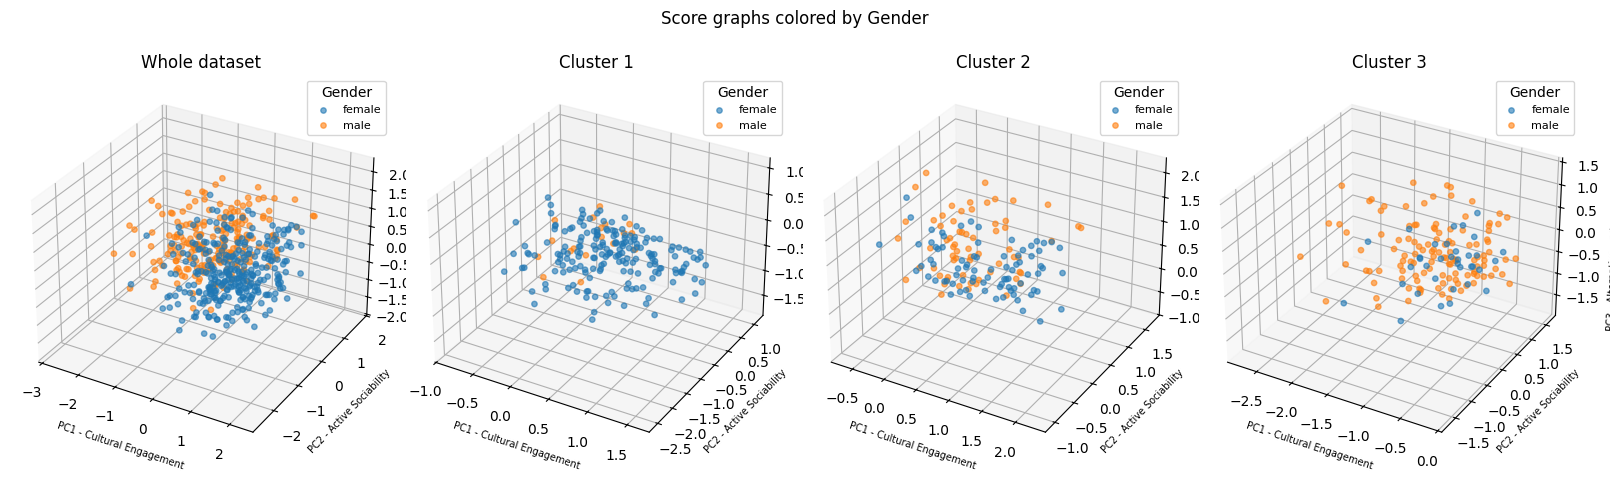

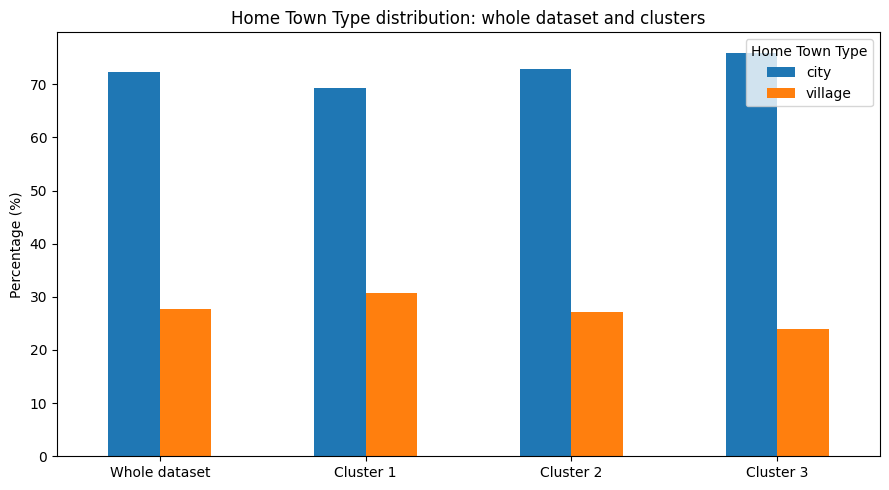

Home Town Type,city,village
Whole dataset,72.3,27.7
Cluster 1,69.3,30.7
Cluster 2,72.8,27.2
Cluster 3,76.0,24.0


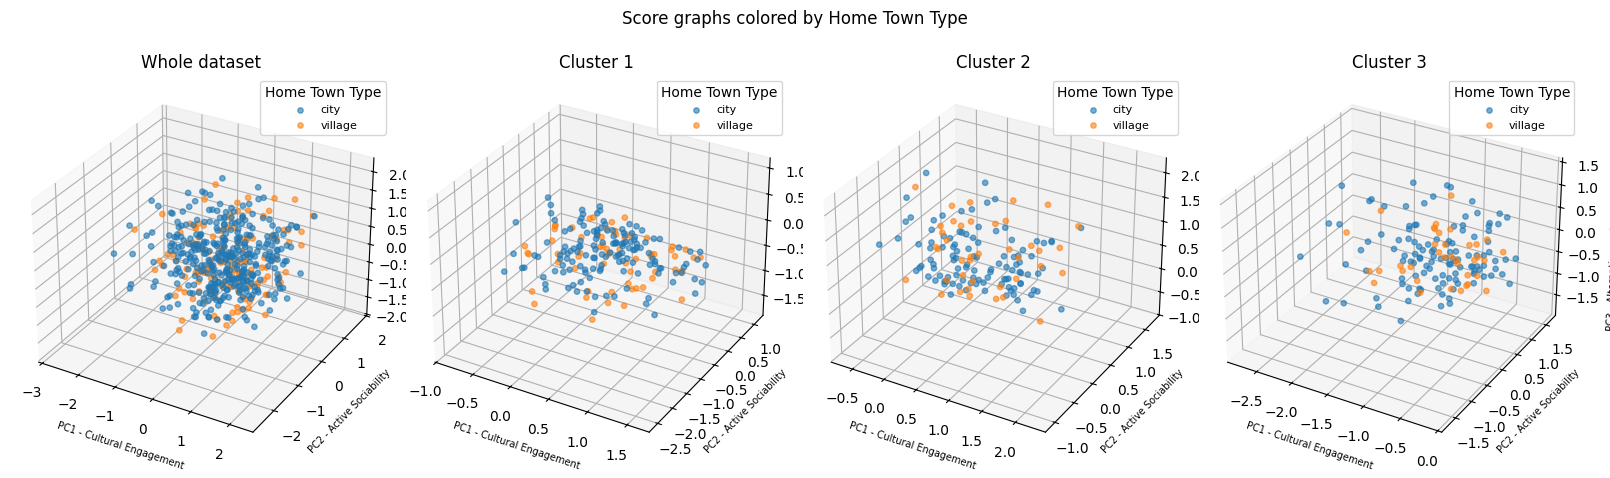

In [ ]:
selected_labels = ['Gender', 'Home Town Type']

evaluation_df = responses_lb.loc[responses_ft_pca.index, selected_labels].copy()
evaluation_df['Cluster'] = cluster_labels + 1
clusters = np.unique(cluster_labels)

for label in selected_labels:
    values = evaluation_df[label]

    # Item 2: distribution of the label in the whole dataset and in each cluster (%)
    overall = values.value_counts(normalize=True) * 100
    per_cluster = pd.crosstab(evaluation_df['Cluster'], values, normalize='index') * 100
    per_cluster.index = [f'Cluster {c}' for c in per_cluster.index]
    distribution_table = pd.concat([overall.to_frame('Whole dataset').T, per_cluster]).fillna(0)

    distribution_table.plot(kind='bar', figsize=(9, 5), rot=0,
                            title=f'{label} distribution: whole dataset and clusters',
                            ylabel='Percentage (%)')
    plt.legend(title=label)
    plt.tight_layout()
    plt.show()
    display(distribution_table.round(1))

    # Item 3: score graph colored by the label (whole dataset), then one score graph per cluster
    categories = values.unique()
    fig = plt.figure(figsize=(16, 5))
    for j, cluster in enumerate([None] + list(clusters)):
        ax = fig.add_subplot(1, len(clusters) + 1, j + 1, projection='3d')
        for i, category in enumerate(categories):
            mask = (values == category).to_numpy()
            if cluster is not None:
                mask &= cluster_labels == cluster
            pts = responses_ft_pca.loc[mask]
            ax.scatter(pts.iloc[:, 0], pts.iloc[:, 1], pts.iloc[:, 2],
                       color=plt.get_cmap('tab10')(i), label=str(category), s=15, alpha=0.6)
        ax.set_xlabel(pc_labels[0], fontsize=7)
        ax.set_ylabel(pc_labels[1], fontsize=7)
        ax.set_zlabel(pc_labels[2], fontsize=7)
        ax.set_title('Whole dataset' if cluster is None else f'Cluster {cluster + 1}')
        ax.legend(title=label, fontsize=8)
    plt.suptitle(f'Score graphs colored by {label}')
    plt.tight_layout()
    plt.show()

#### For each selected label, comment the results observed in the visualizations (max 100 words per label):

-   **Gender:**
    -    Gender is strongly related to the clusters. Females are 60% of the dataset, but 91% of Cluster 1 (Reserved Mainstream) and only 23% of Cluster 3 (Low Cultural Engagement), which is 77% male.
    -   Cluster 2 (Active and Curious) is balanced (56% female). The score graphs confirm this: female points concentrate on the positive side of PC1 and the negative side of PC3, males on the opposite side. 
    -   So the first PCs, and therefore the clusters, partly capture gender-related differences in interests.

-   **Home Town Type:**
    -   The distributions are almost identical: about 72% city and 28% village in the whole dataset and in every cluster (69–76% city). In the score graphs city and village points are completely mixed. Home town type is not related to the clusters found by k-Means.

## Exercise 6. Cluster Internal Evaluations

In this exercise, you have to do the following operations:
1. For each cluster, measure the corresponding average silhouette score
1. Visualize the silhouette of the clusters and the general one of the clustering and compare them


#### Write the code for computing the silhouette scores and for visualizing them:

In [ ]:
# 1. Average silhouette score of each cluster
sample_scores = silhouette_samples(responses_ft_pca, cluster_labels)   # one score per sample

for cluster in np.unique(cluster_labels):
    mean_score = sample_scores[cluster_labels == cluster].mean()
    print(f'Cluster {cluster + 1}: {mean_score:.4f}')

print(f'\nOverall silhouette score: {sample_scores.mean():.4f}')

# 2. Silhouette plot of the clusters, with the overall average of the clustering
plt.figure(figsize=(9, 7))
y_lower = 10

for cluster in np.unique(cluster_labels):
    scores = np.sort(sample_scores[cluster_labels == cluster])
    y_upper = y_lower + len(scores)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, scores, alpha=0.7, label=f'Cluster {cluster + 1}')
    y_lower = y_upper + 10

plt.axvline(sample_scores.mean(), color='red', linestyle='--',
            label=f'Overall average: {sample_scores.mean():.3f}')

plt.xlabel('Silhouette Score')
plt.ylabel('Samples grouped by cluster')
plt.title('Silhouette Plot')
plt.yticks([])
plt.xlim(-1, 1)
plt.legend()
plt.tight_layout()
plt.show()

#### Comment the results, also considering the results observed previously (e.g., score graphs, centroids, etc. - max 150 words):
-   The overall silhouette score is 0.166: positive, but low. The clusters exist, but they are not well separated.

-   Cluster 1 (Reserved Mainstream) has the best score (0.189) and no negative values; Cluster 2 (Active and Curious) has the lowest (0.144) and some negative values, so part of its samples are closer to another cluster.

-   This agrees with the score graphs of Exercise 4: the three groups overlap in the centre and are separated only at the borders.

-   It also agrees with the centroids: they differ only on PC1-PC3, with small distances, and PC4-PC5 do not separate them at all.

-   The low score is expected for survey data: the 5 PCs keep only 25.8% of the variance, so the clusters are built on a limited part of the information. However, the external evaluation with Gender showed that the clusters still capture a real structure.